# MCA Signal Extraction
---

In [2]:
%%time
import mcaap
import glob, datetime, warnings, utm, sys
sys.path.append('/Path/to/Cardinal') # NOTE: change to your Cardinal directory location
# import cardinal # uncomment this line when path is set
#-----------------------------------------------------------------------------------------------------------------#
# Command to make all plots interactive
%matplotlib ipympl

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from obspy import *
from obspy.core import *
from scipy import signal
from pyproj import Geod; g = Geod(ellps='sphere')

warnings.filterwarnings('ignore')

# Global data directories (please read data details in GitHub repository)
MCA_dir = '/Volumes/Extreme SSD/McAAP/Winter_2021/'

CPU times: user 586 ms, sys: 139 ms, total: 725 ms
Wall time: 1.15 s


## Plotting MCA Data for Each Day
---
#### Need to determine days in which observations were made

<IPython.core.display.Javascript object>


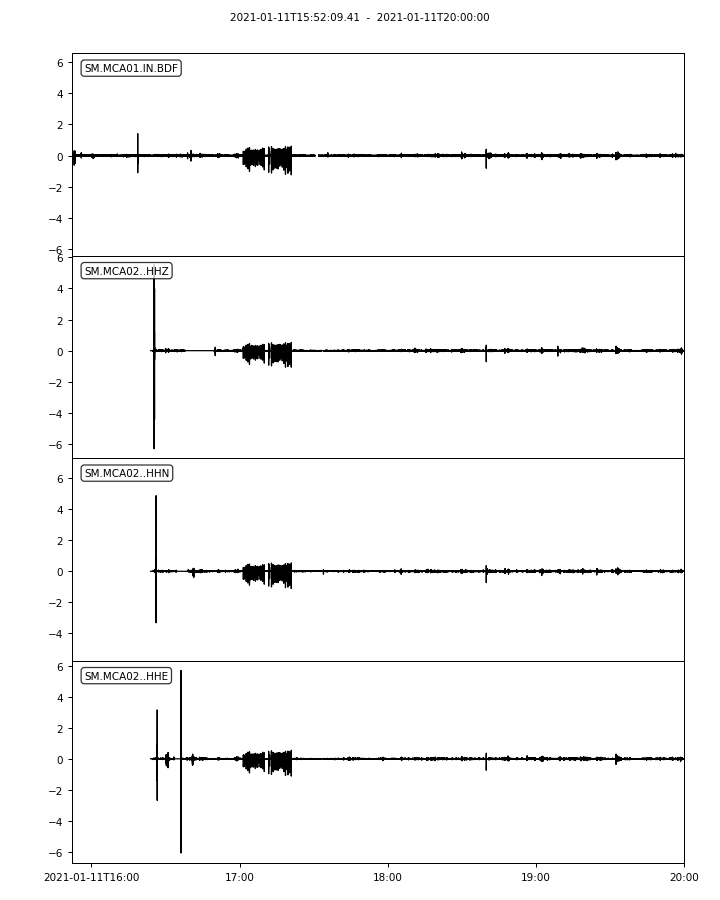

<IPython.core.display.Javascript object>


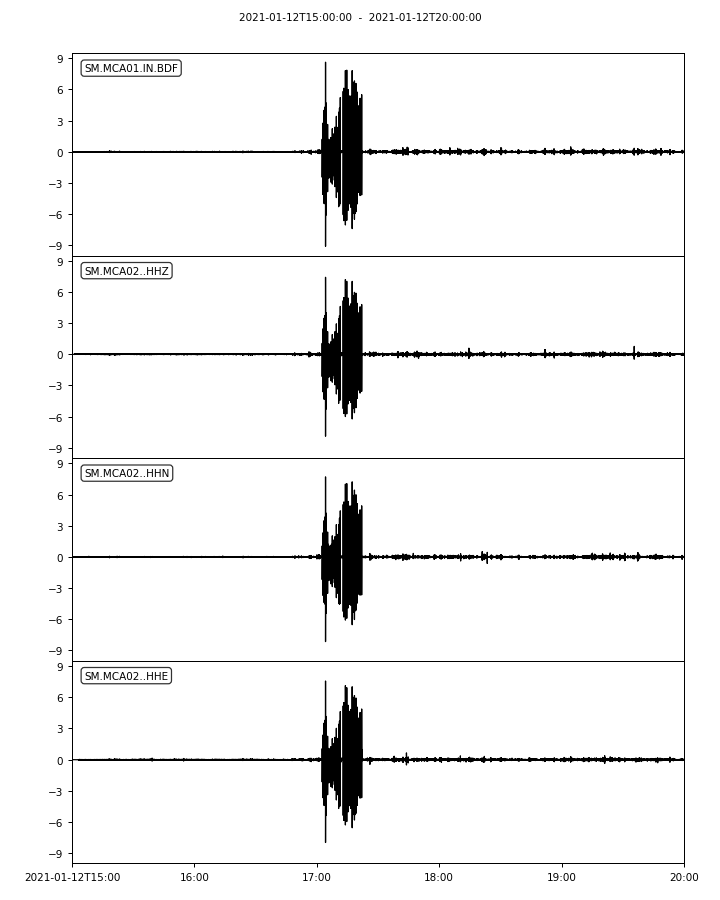

<IPython.core.display.Javascript object>


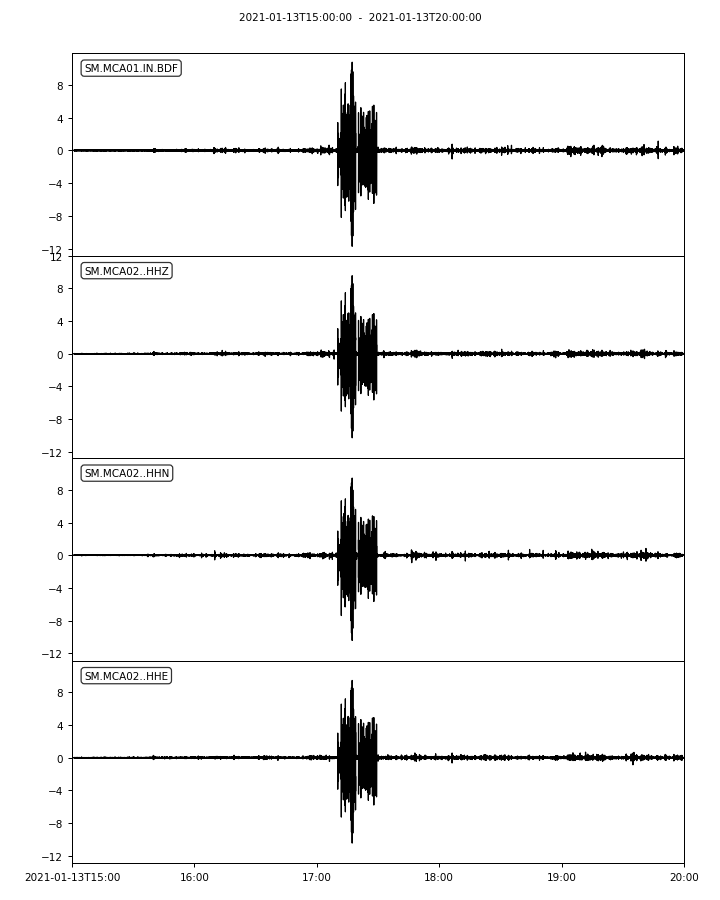

<IPython.core.display.Javascript object>


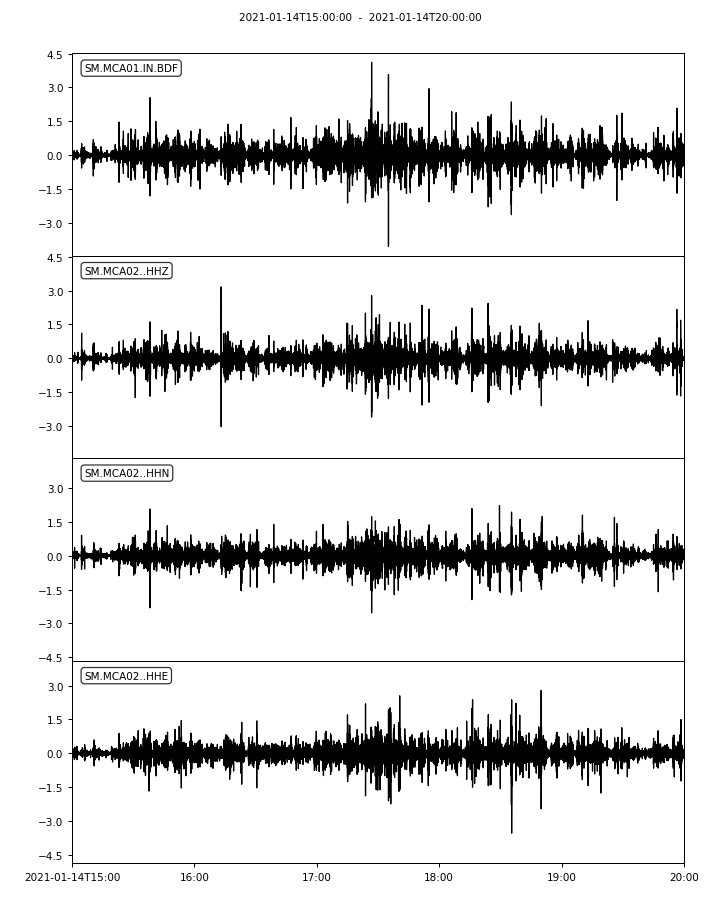

<IPython.core.display.Javascript object>


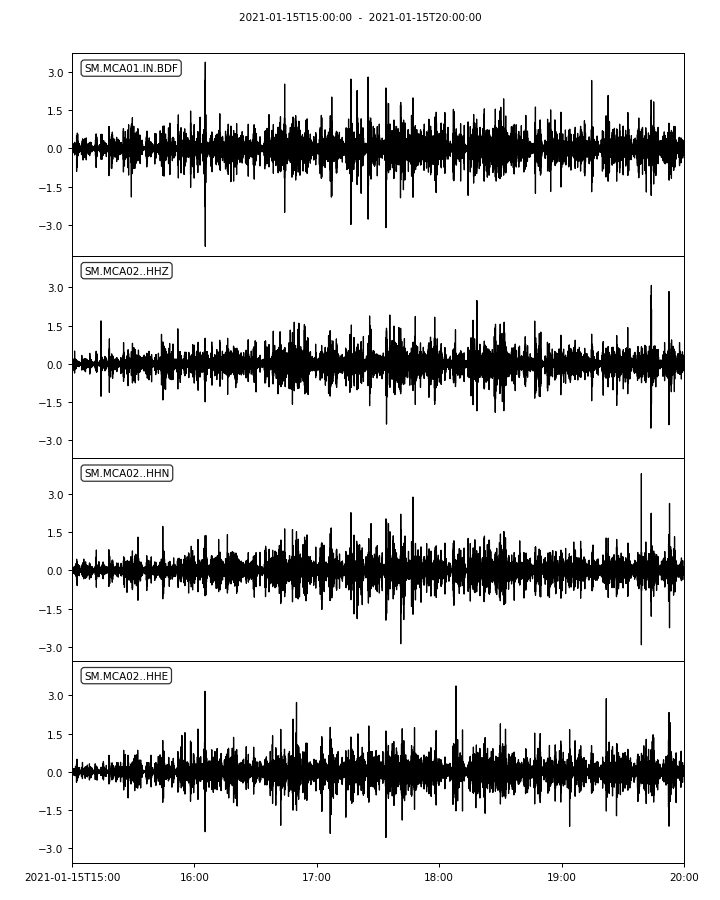

<IPython.core.display.Javascript object>


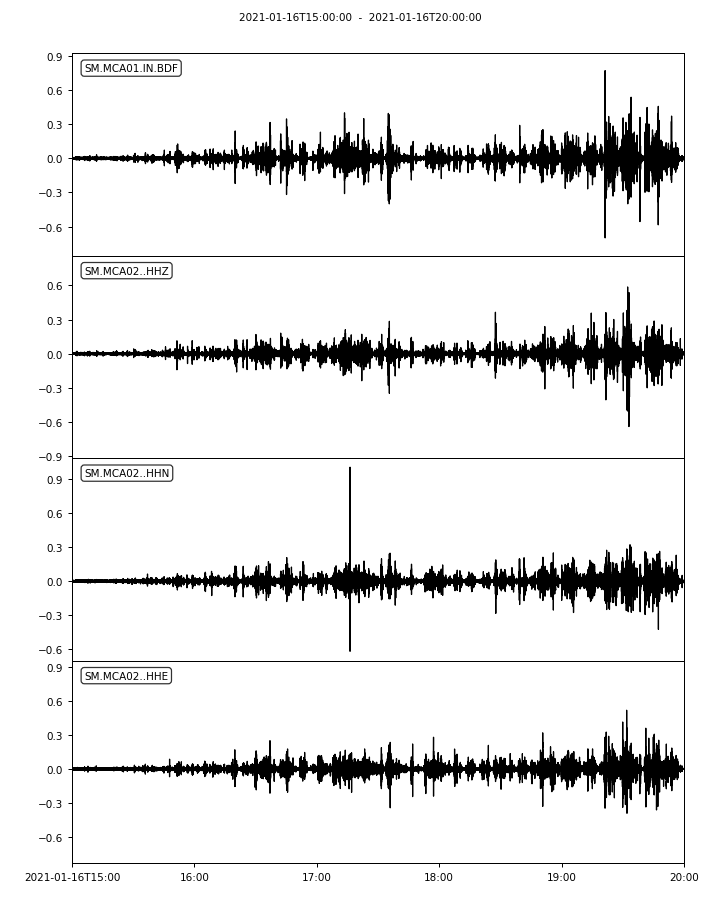

<IPython.core.display.Javascript object>


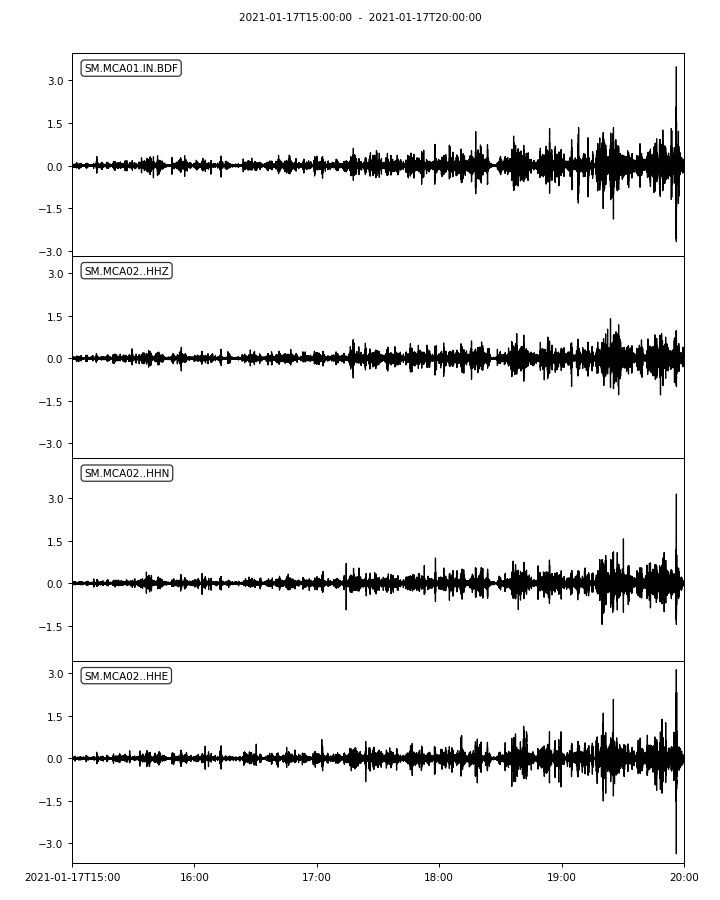

<IPython.core.display.Javascript object>


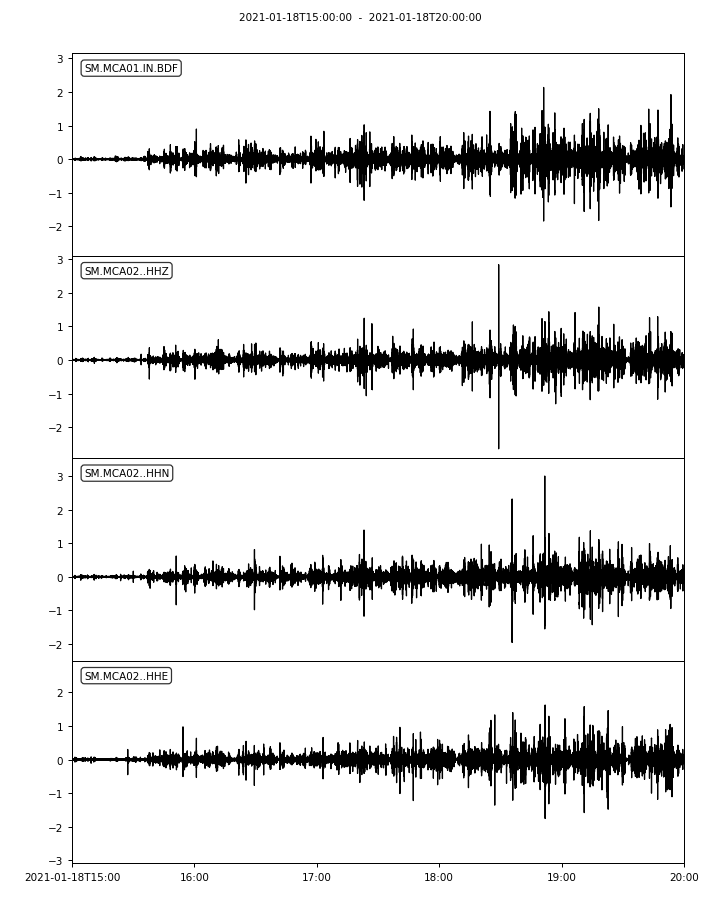

<IPython.core.display.Javascript object>


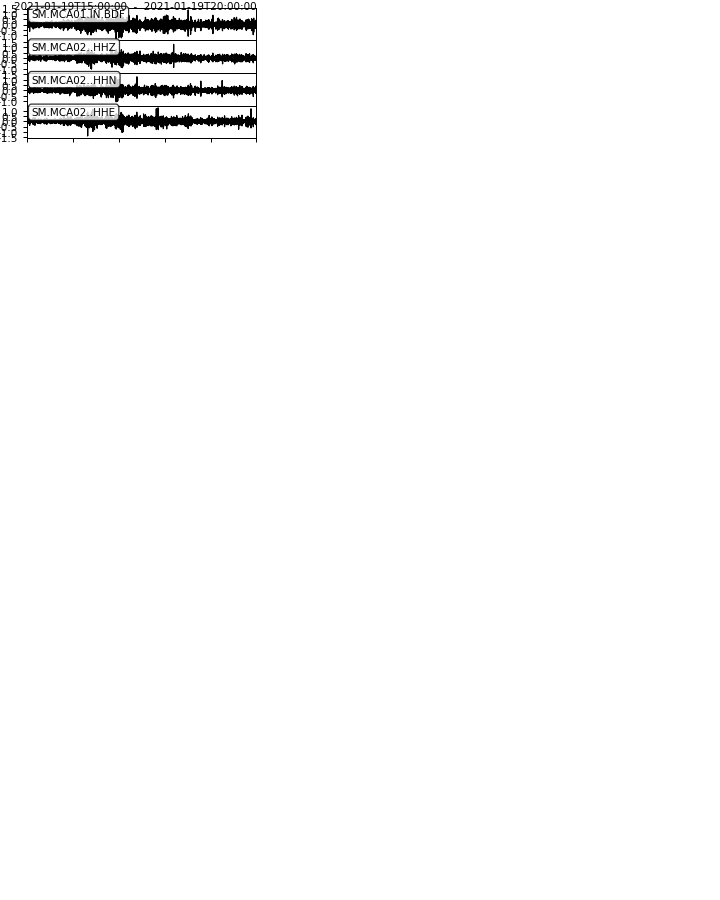

<IPython.core.display.Javascript object>


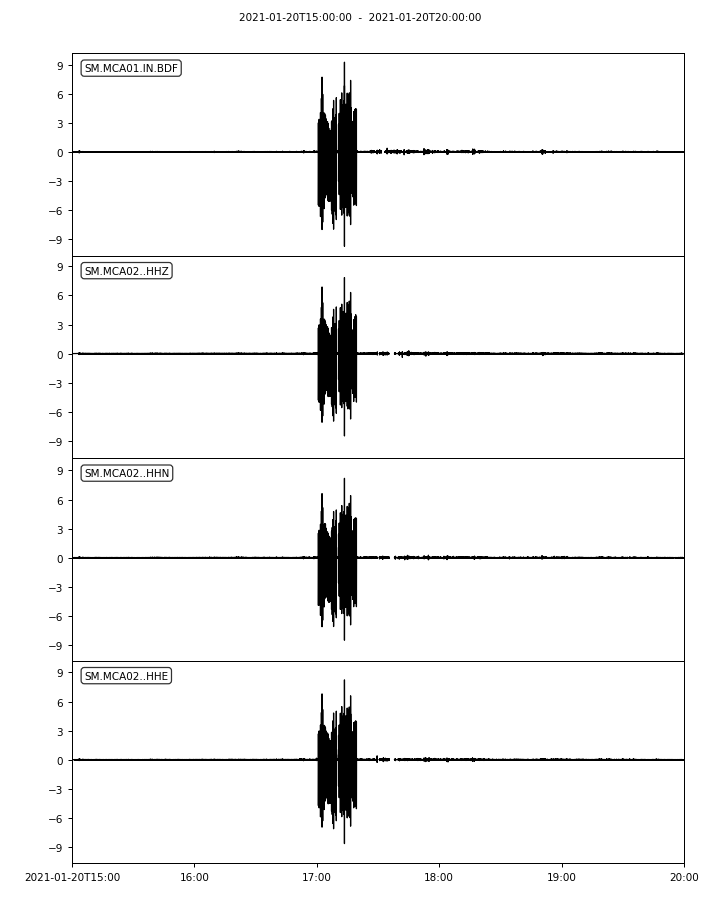

<IPython.core.display.Javascript object>


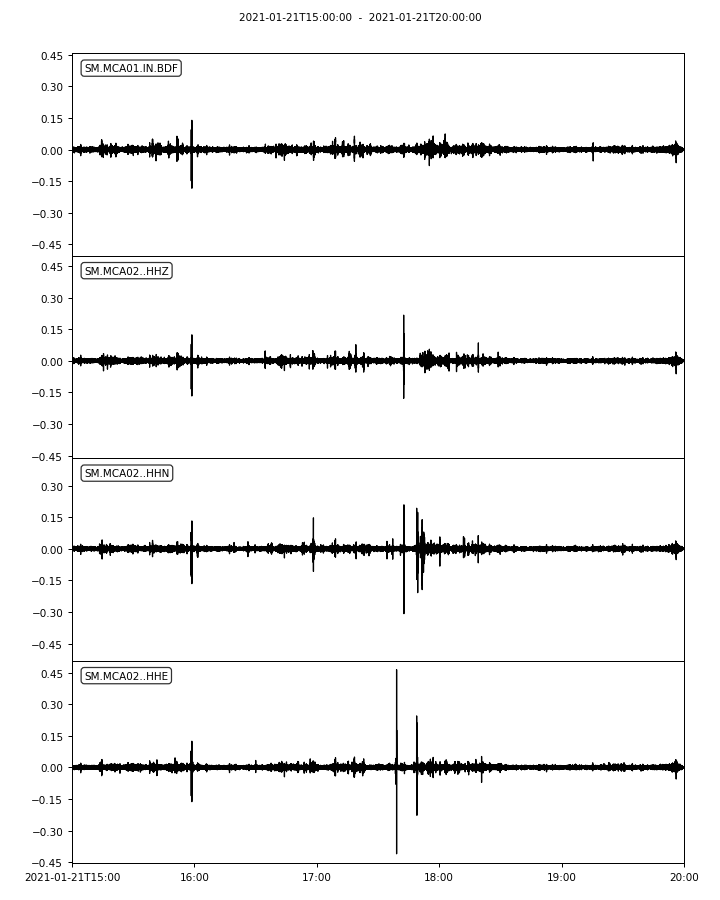

<IPython.core.display.Javascript object>


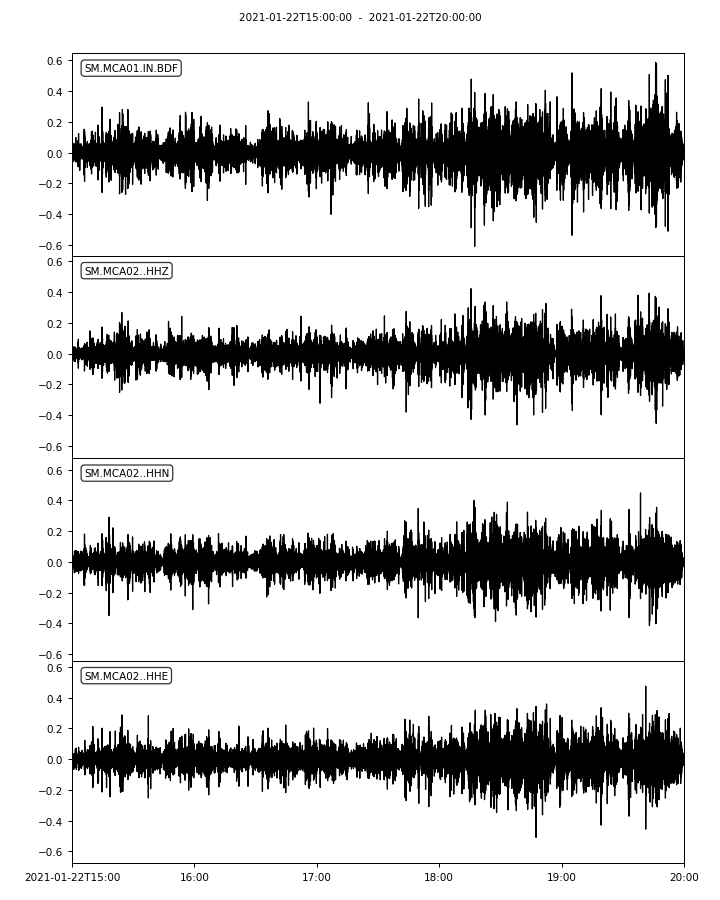

<IPython.core.display.Javascript object>


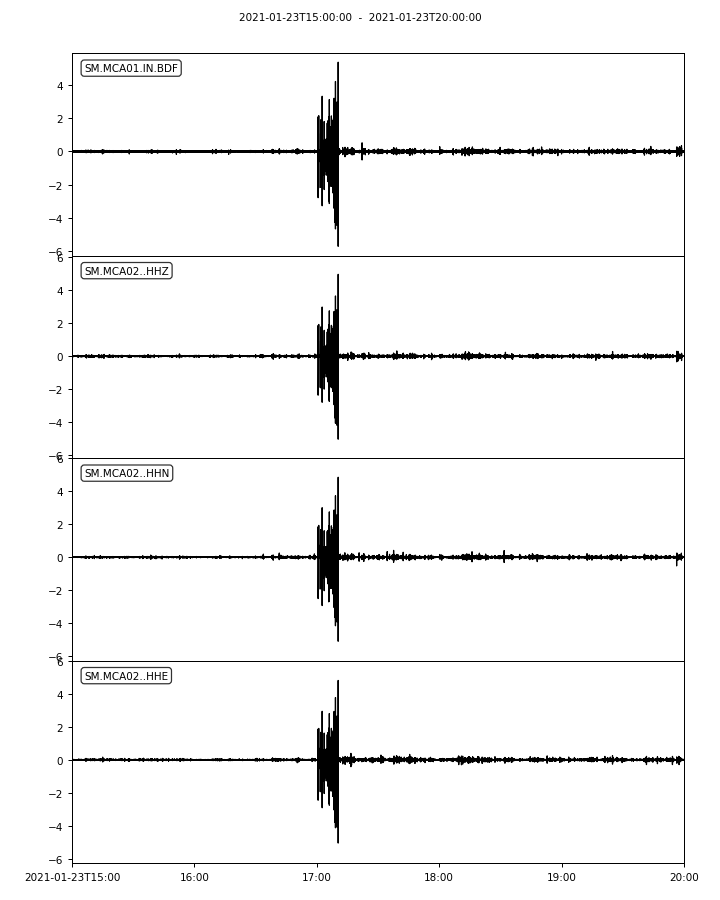

<IPython.core.display.Javascript object>


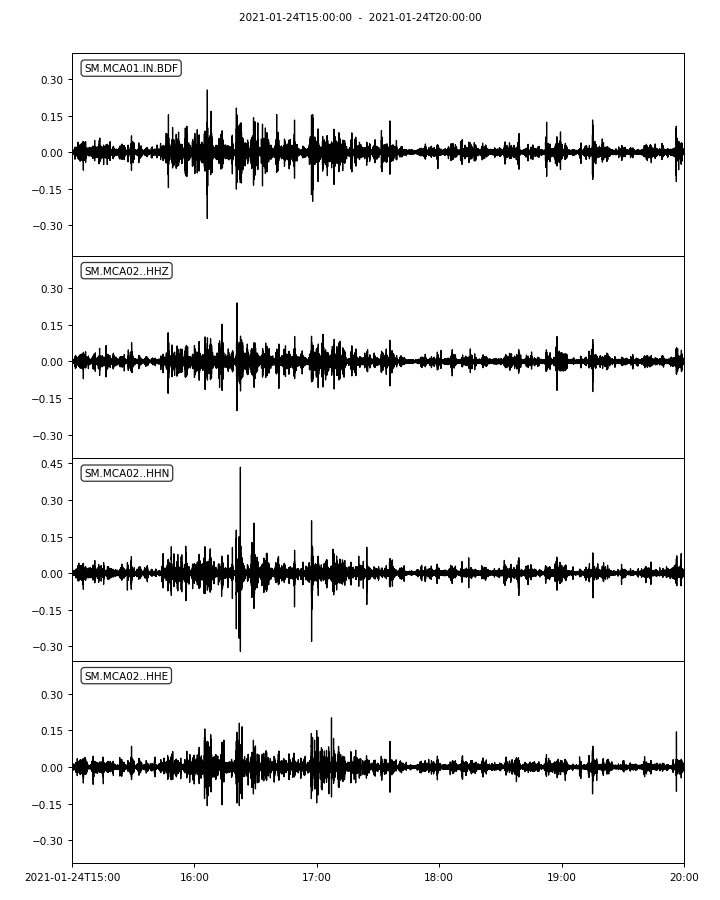

<IPython.core.display.Javascript object>


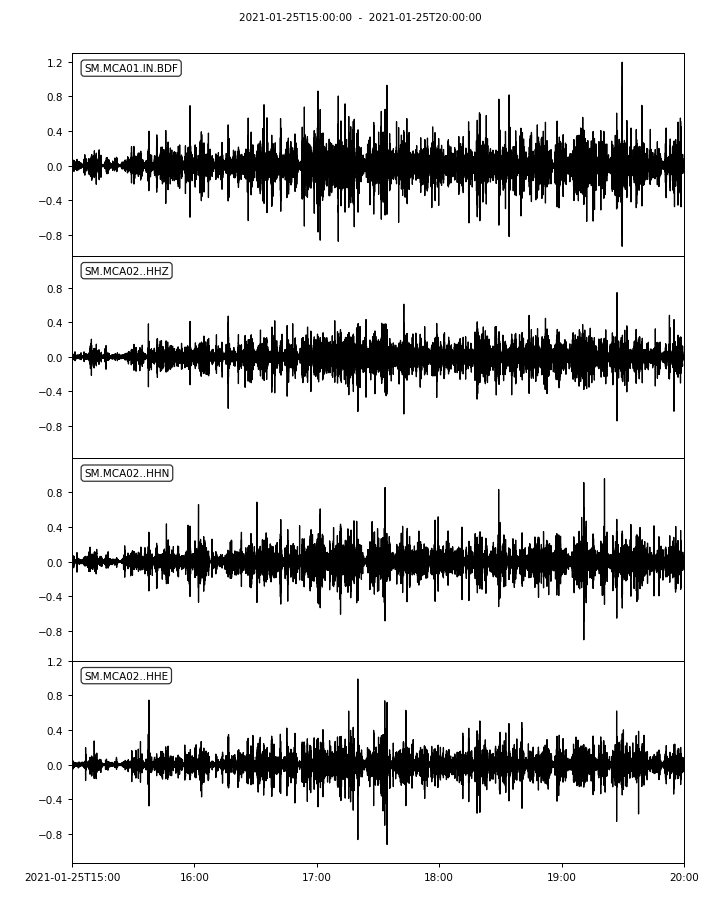

<IPython.core.display.Javascript object>


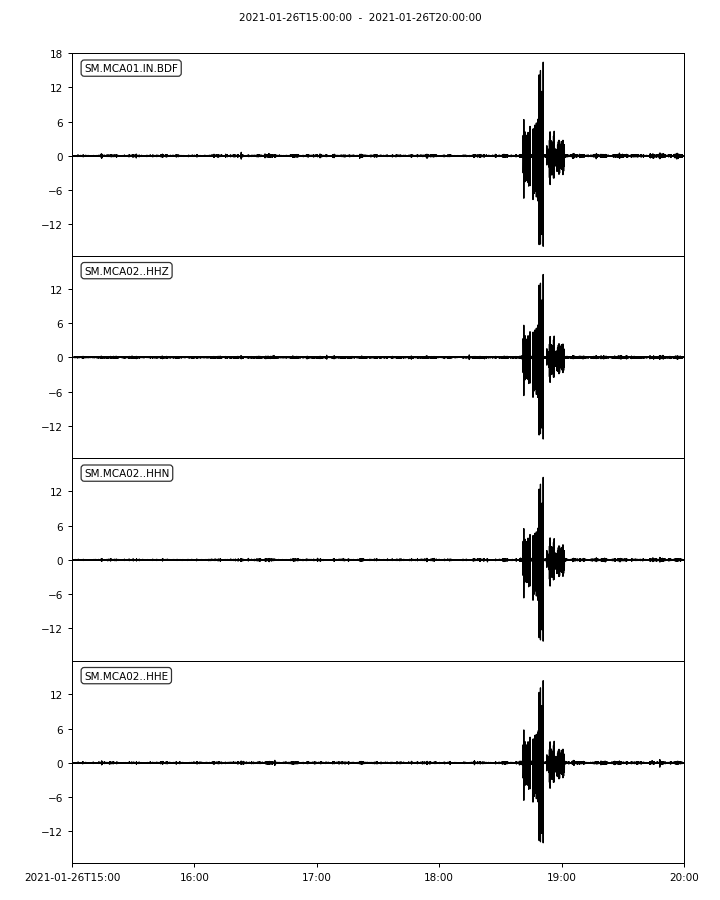

<IPython.core.display.Javascript object>


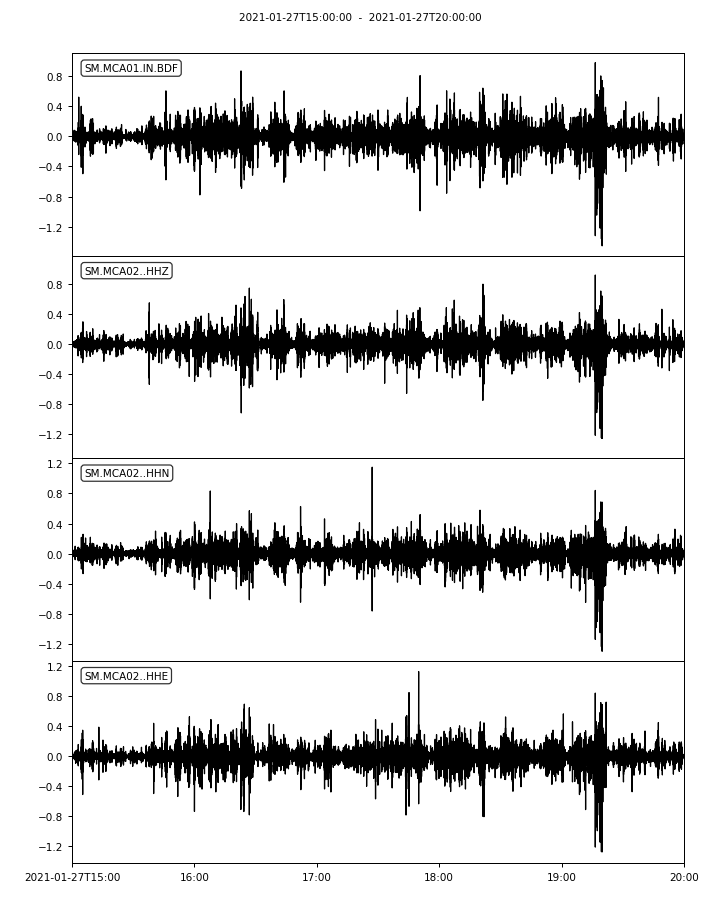

<IPython.core.display.Javascript object>


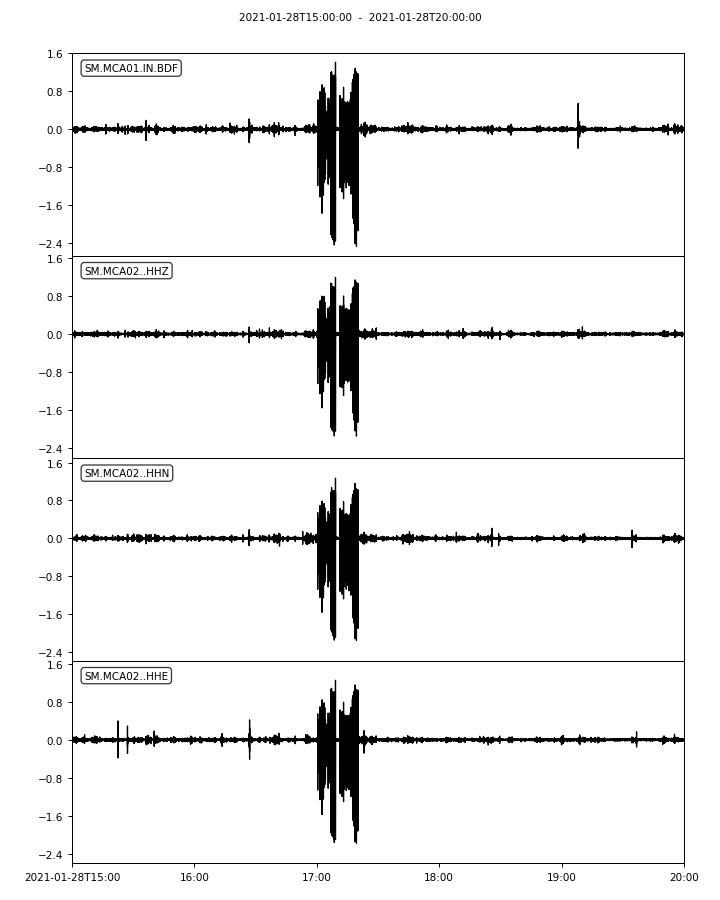

<IPython.core.display.Javascript object>


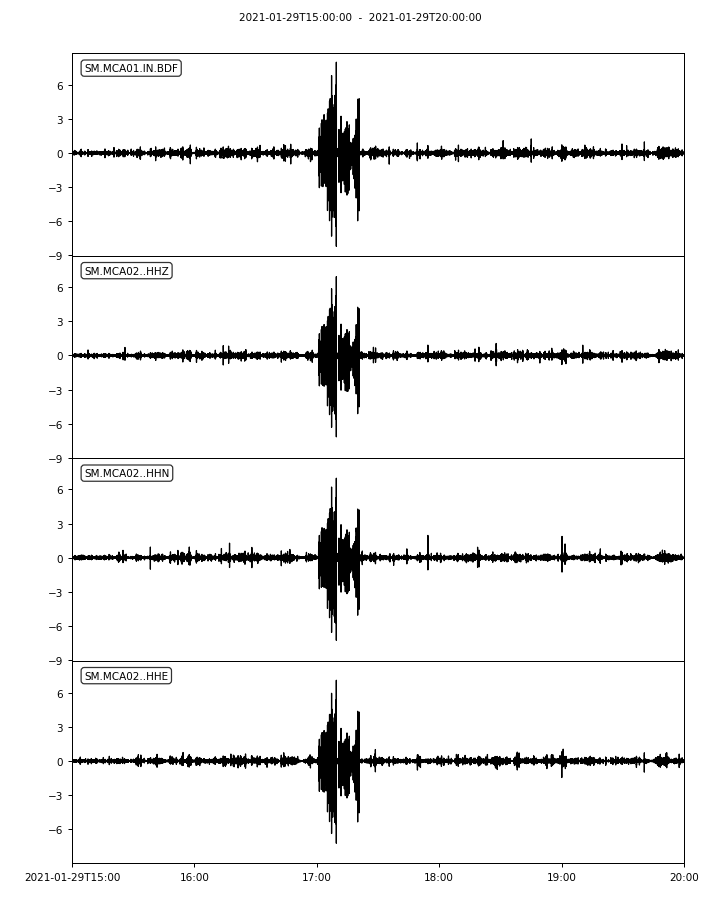

<IPython.core.display.Javascript object>


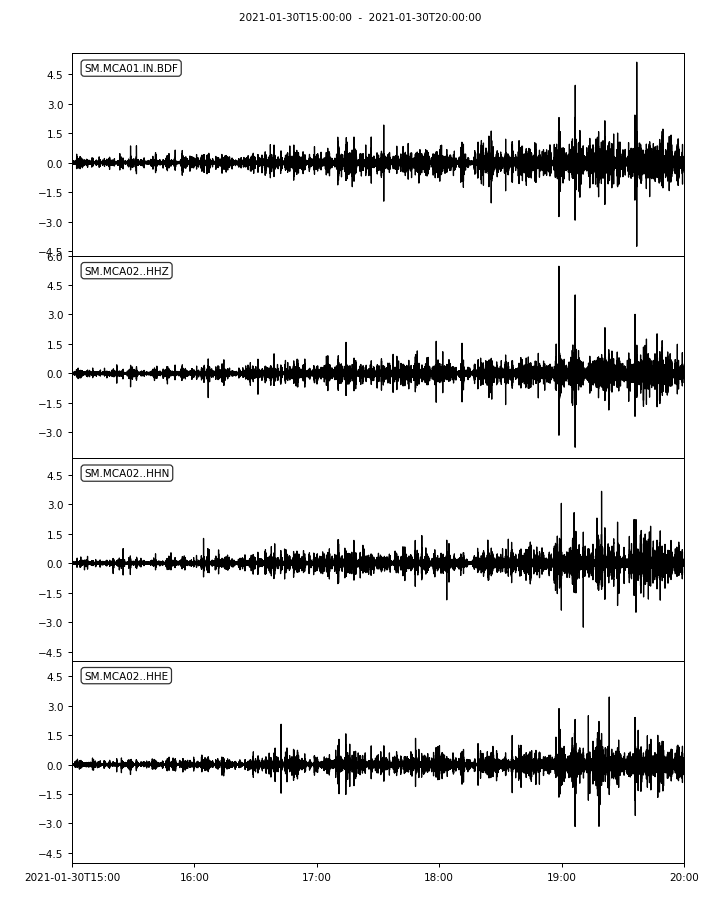

<IPython.core.display.Javascript object>


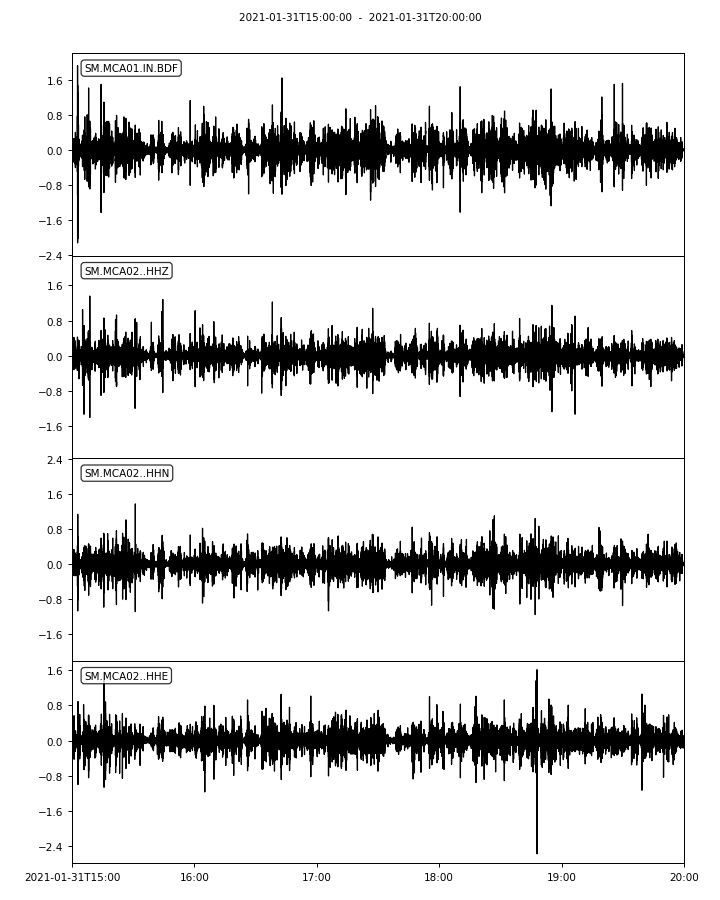

<IPython.core.display.Javascript object>


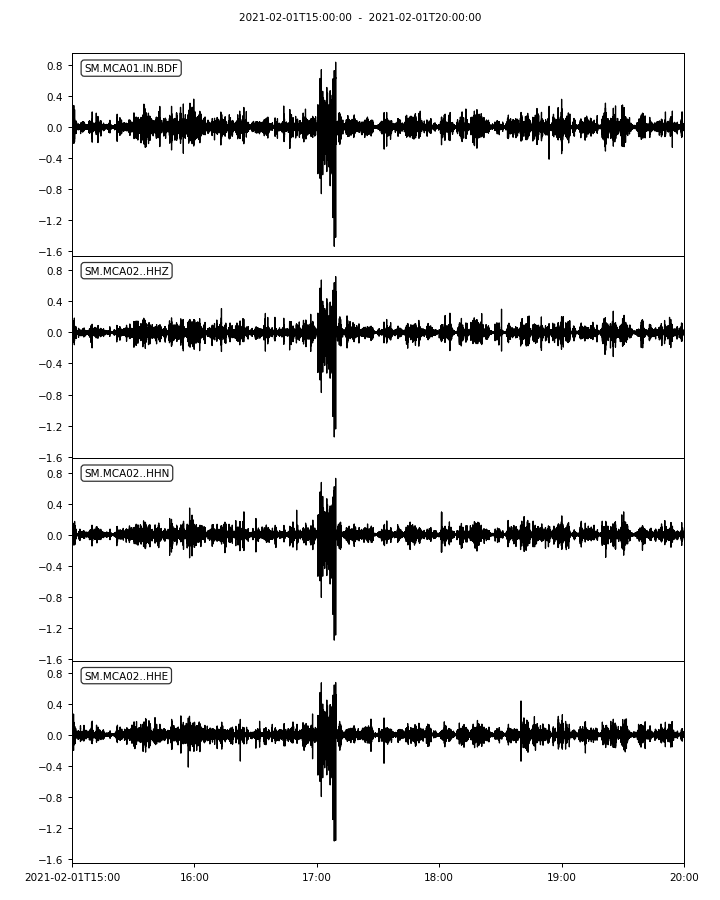

<IPython.core.display.Javascript object>


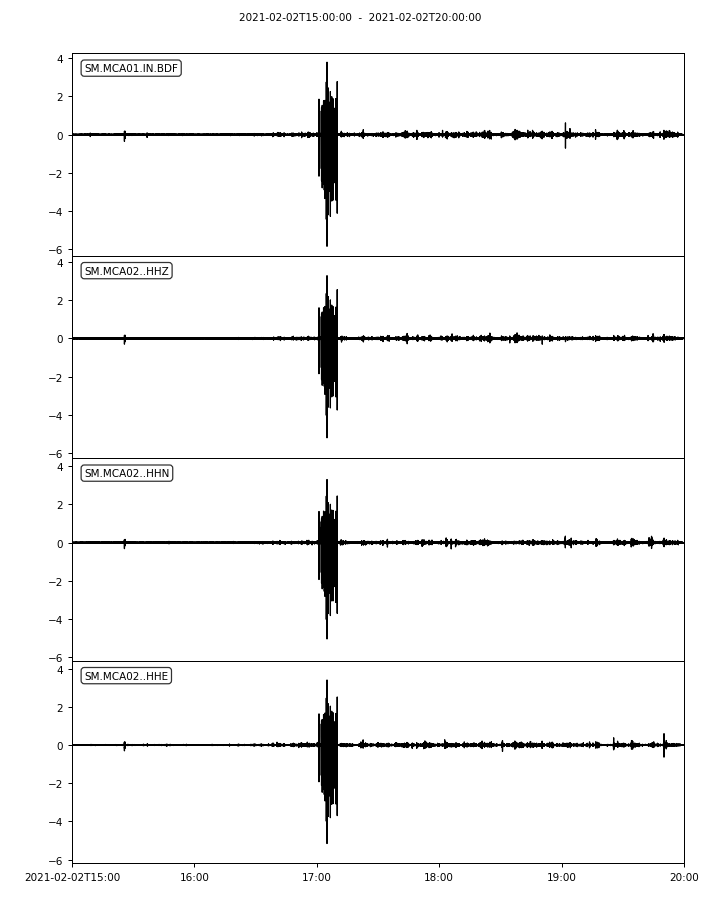

<IPython.core.display.Javascript object>


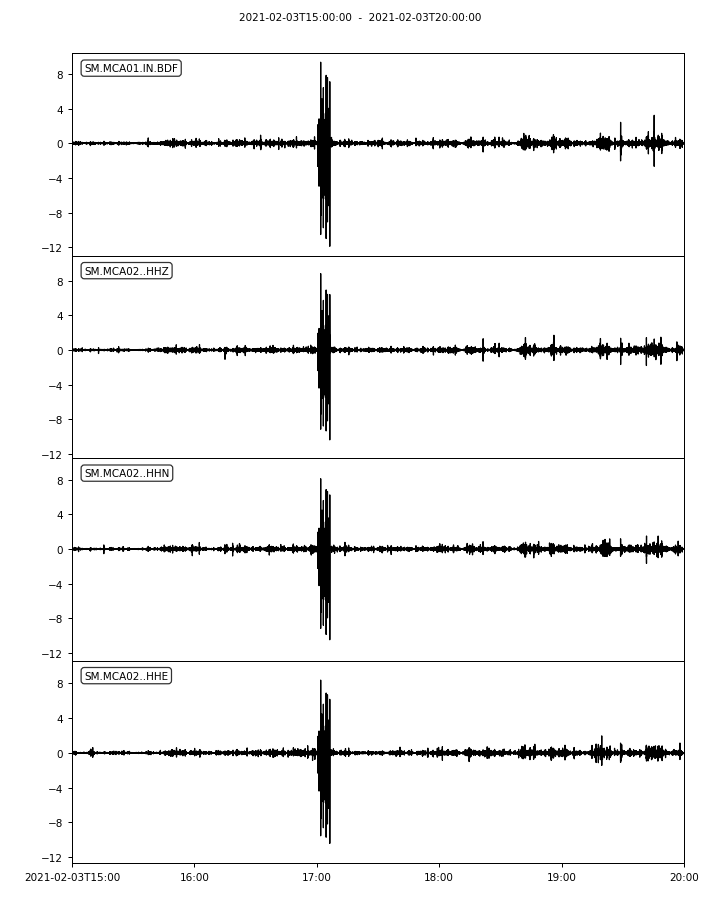

<IPython.core.display.Javascript object>


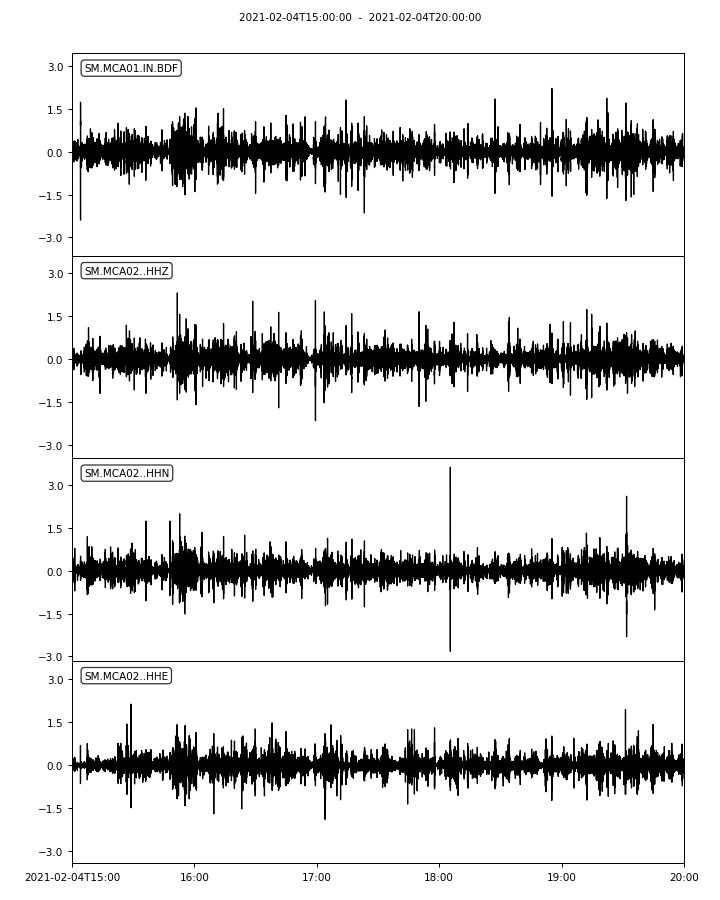

<IPython.core.display.Javascript object>


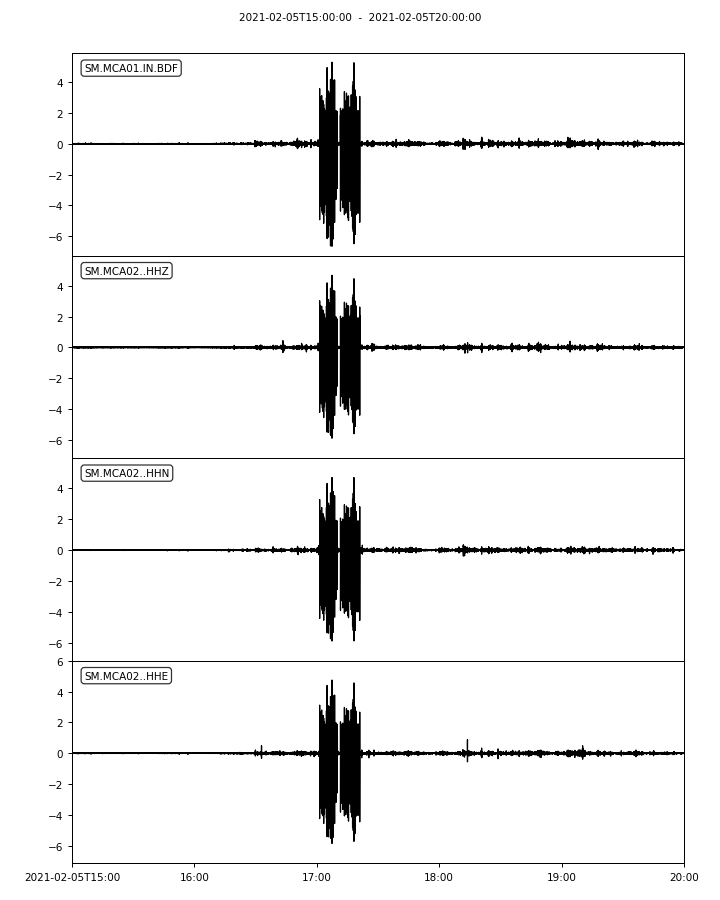

<IPython.core.display.Javascript object>


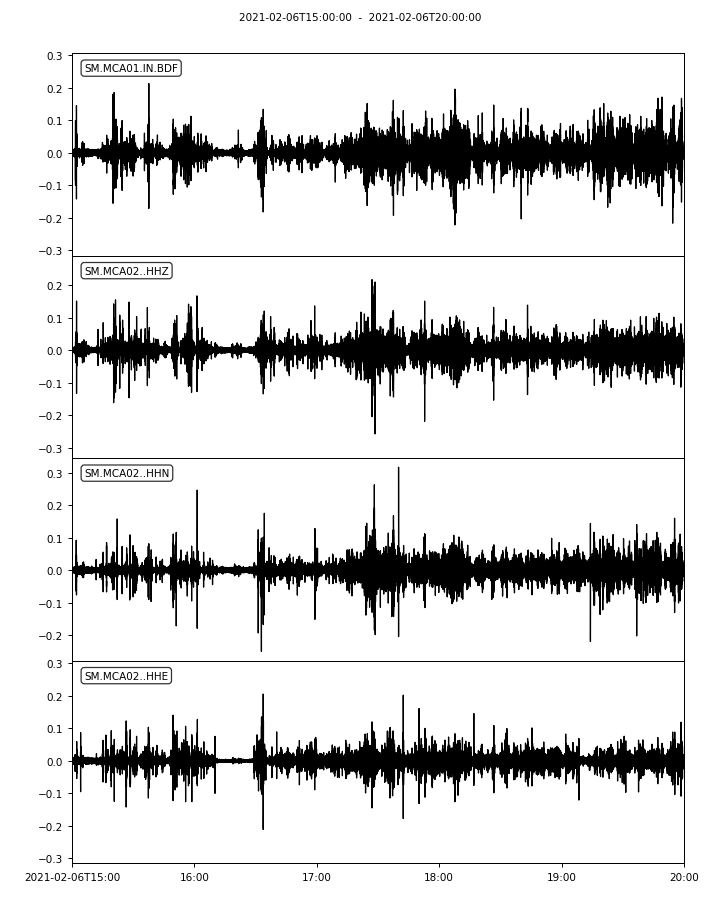

<IPython.core.display.Javascript object>


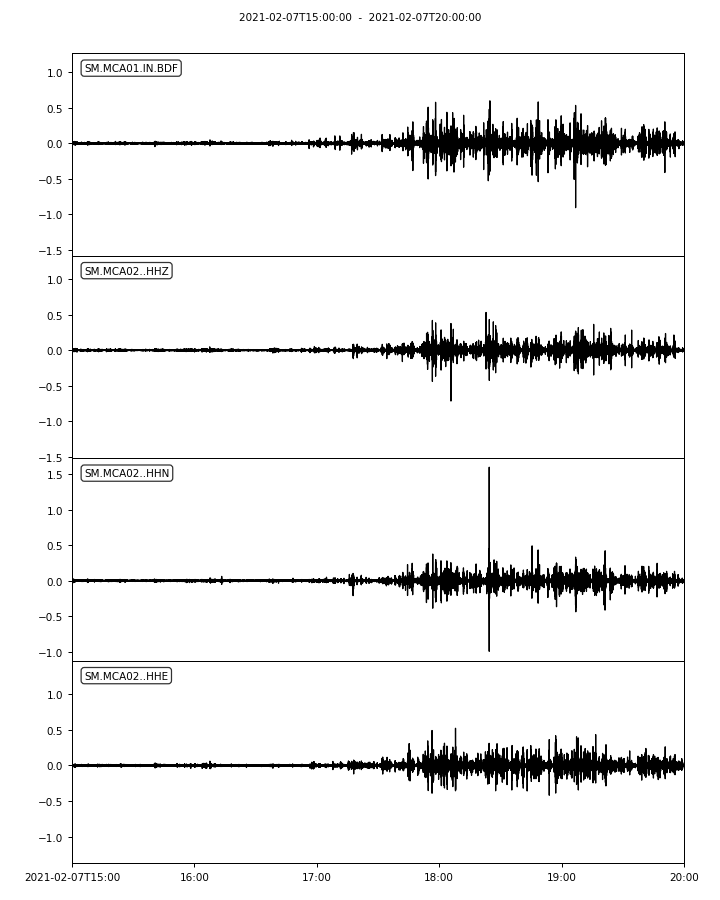

<IPython.core.display.Javascript object>


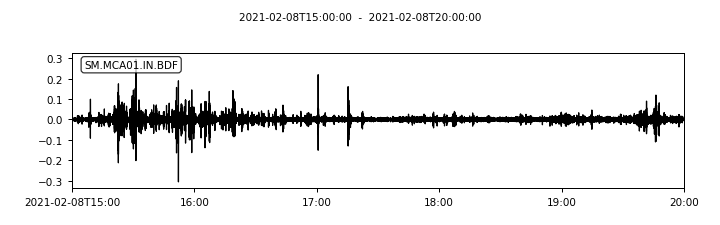

<IPython.core.display.Javascript object>


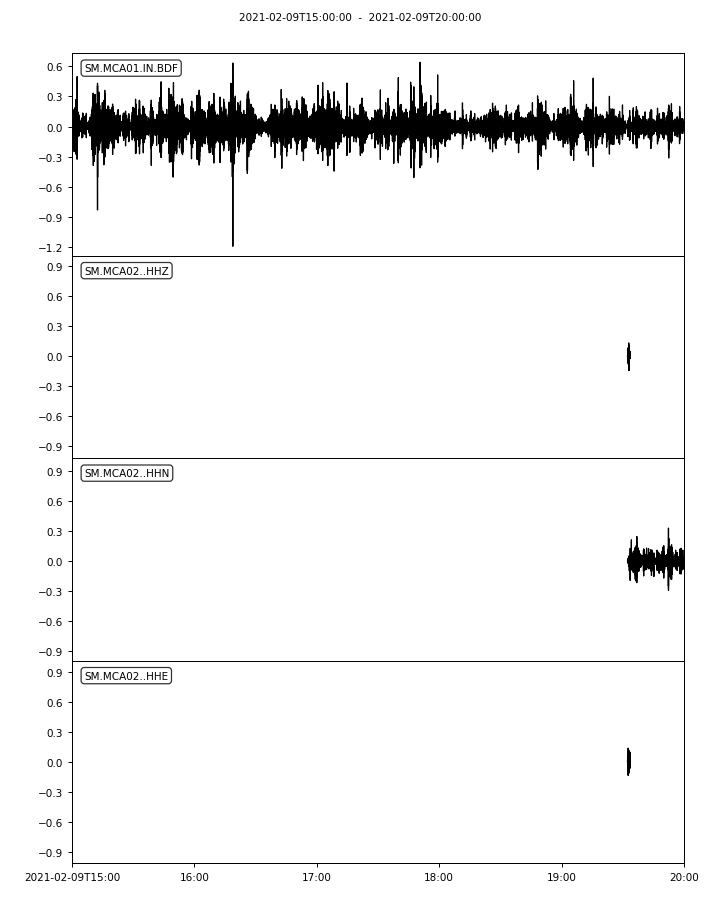

<IPython.core.display.Javascript object>


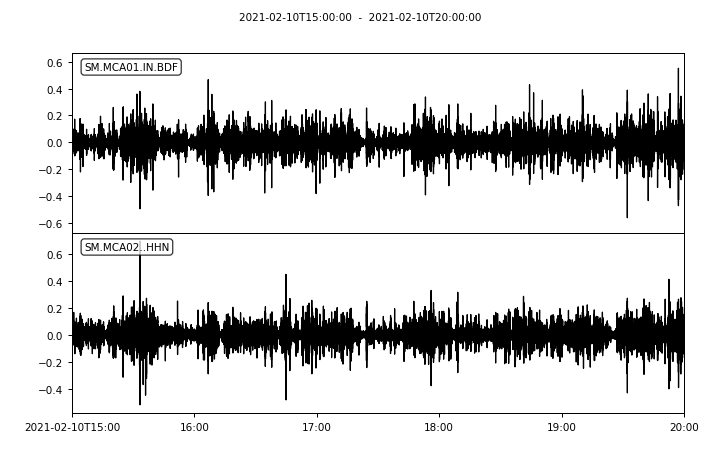

<IPython.core.display.Javascript object>


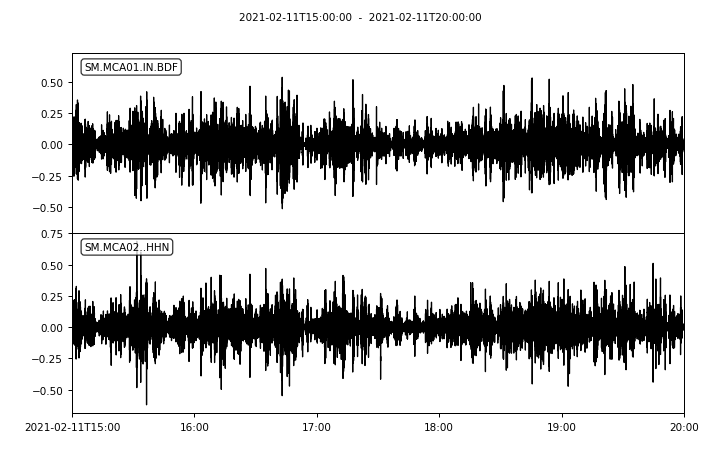

<IPython.core.display.Javascript object>


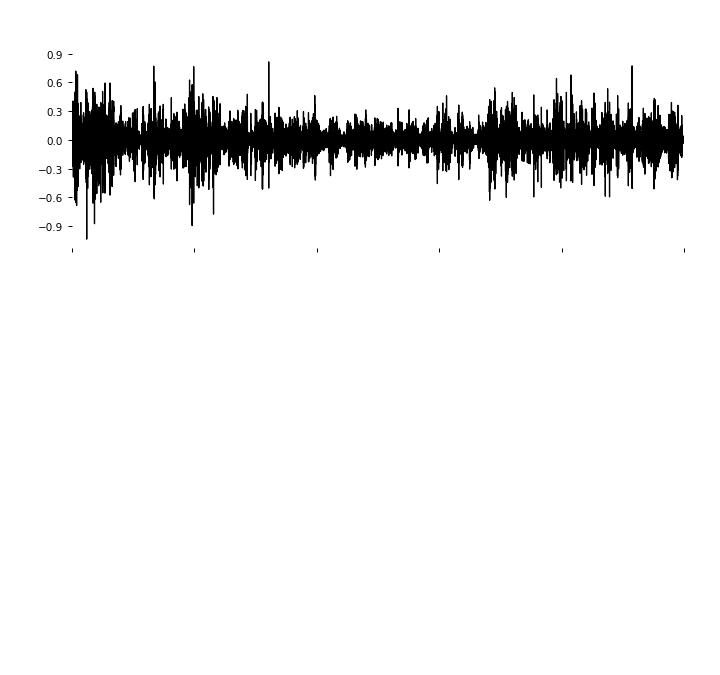

<IPython.core.display.Javascript object>


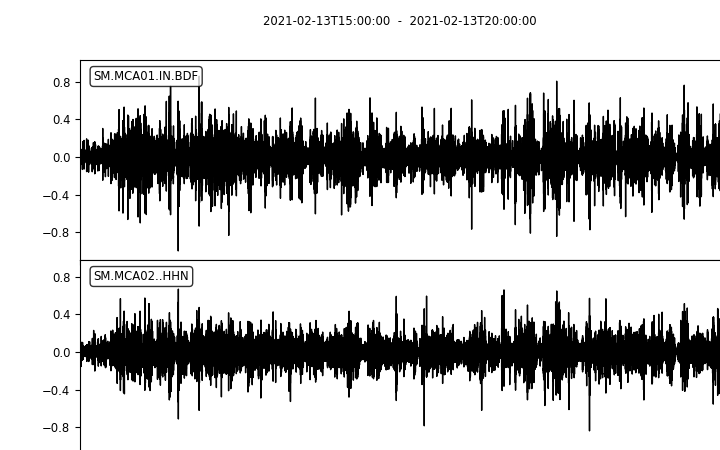

<IPython.core.display.Javascript object>


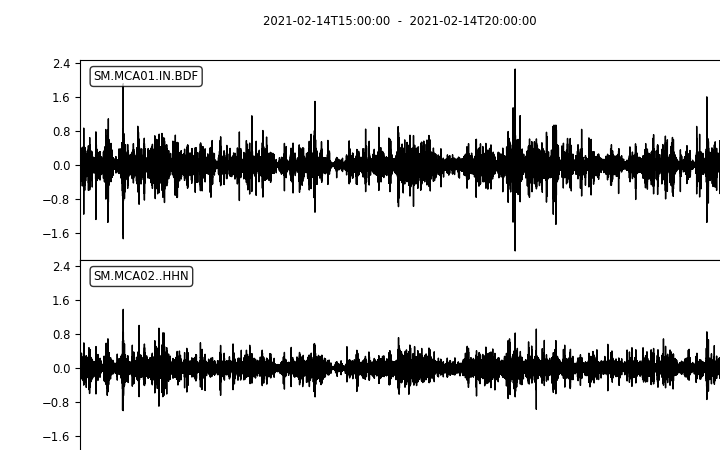

<IPython.core.display.Javascript object>


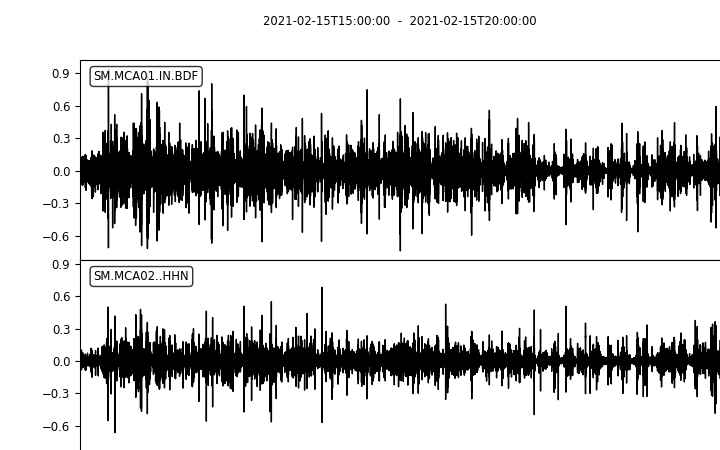

<IPython.core.display.Javascript object>


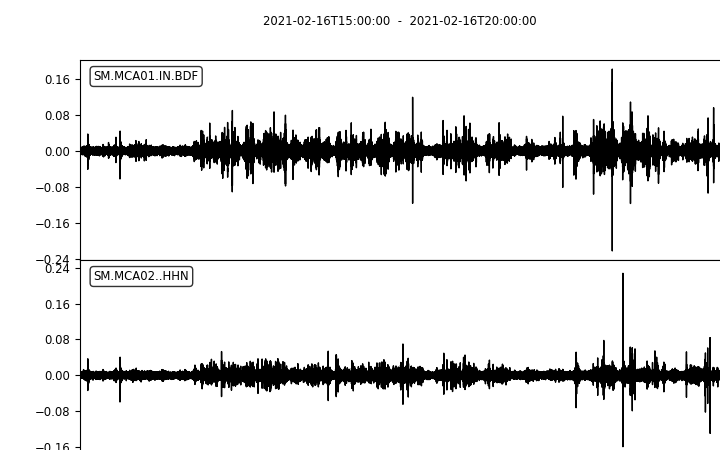

<IPython.core.display.Javascript object>


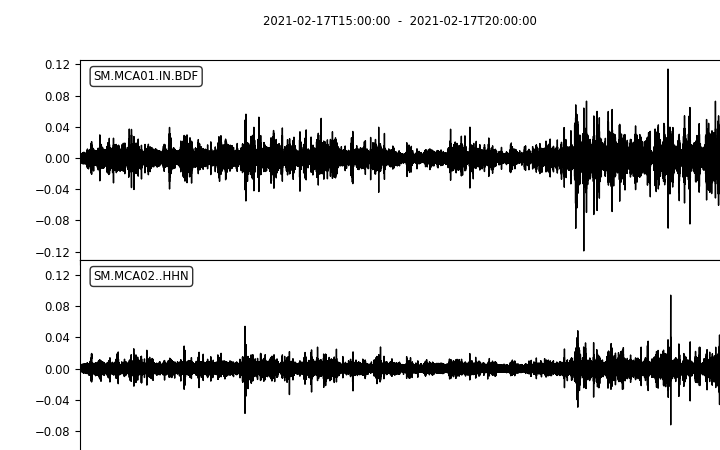

<IPython.core.display.Javascript object>


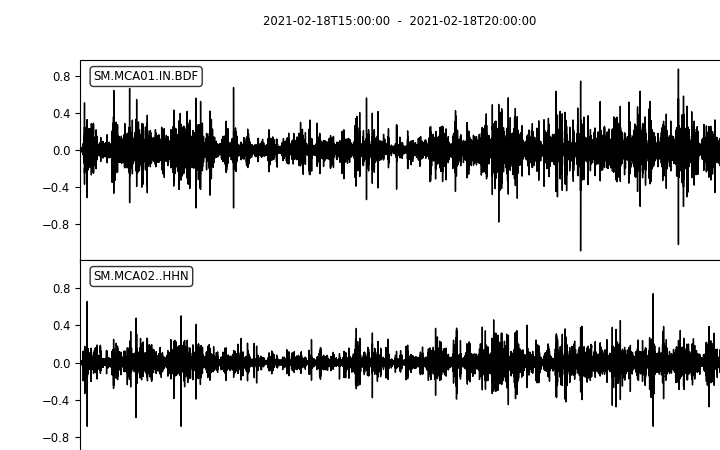

<IPython.core.display.Javascript object>


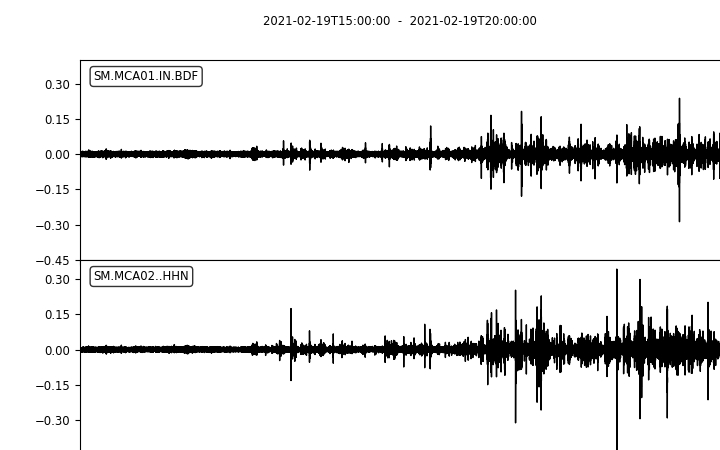

<IPython.core.display.Javascript object>


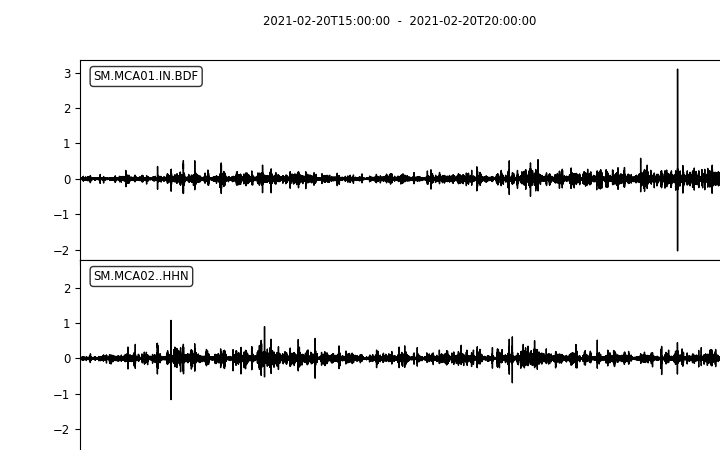

<IPython.core.display.Javascript object>


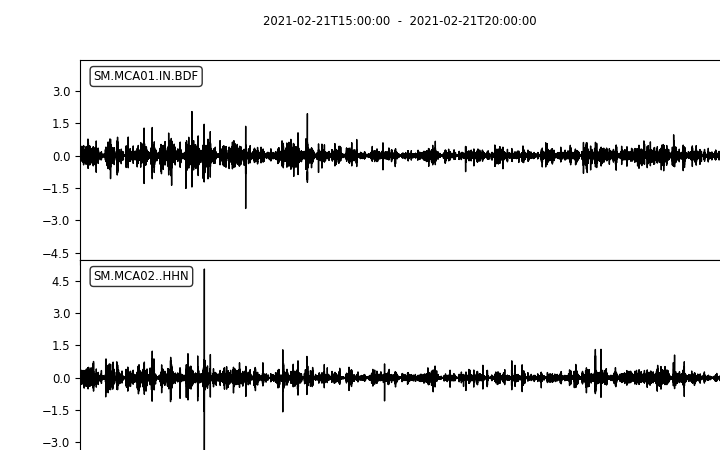

<IPython.core.display.Javascript object>


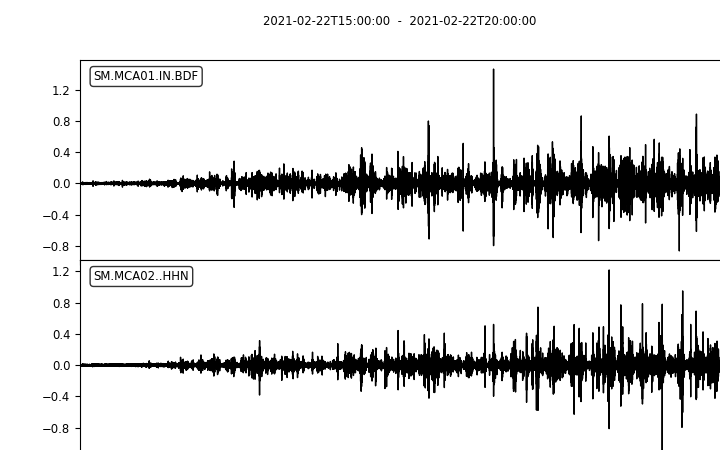

<IPython.core.display.Javascript object>


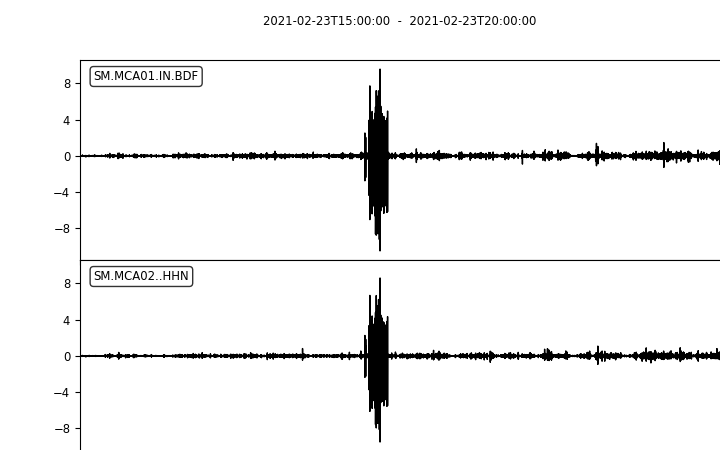

<IPython.core.display.Javascript object>


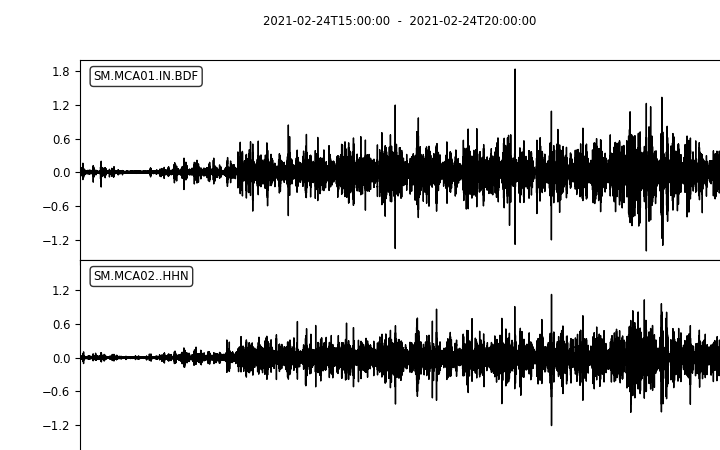

<IPython.core.display.Javascript object>


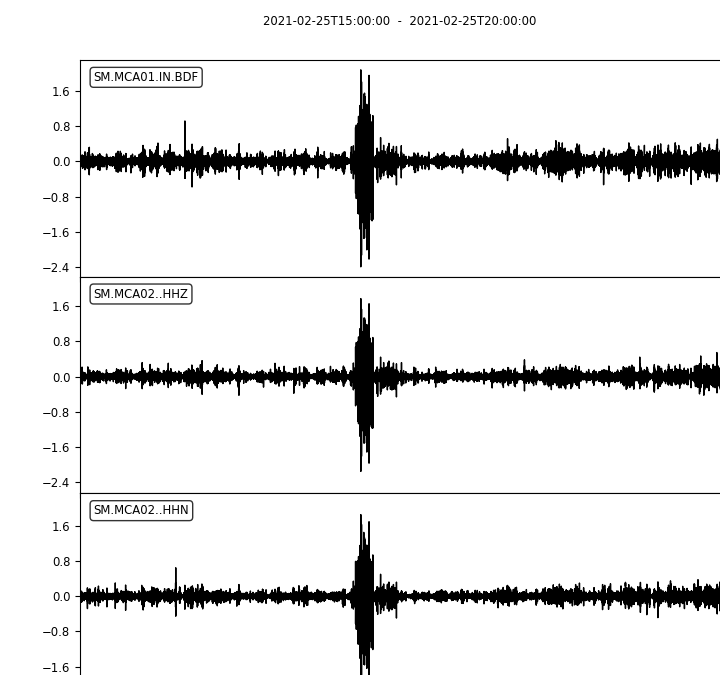

<IPython.core.display.Javascript object>


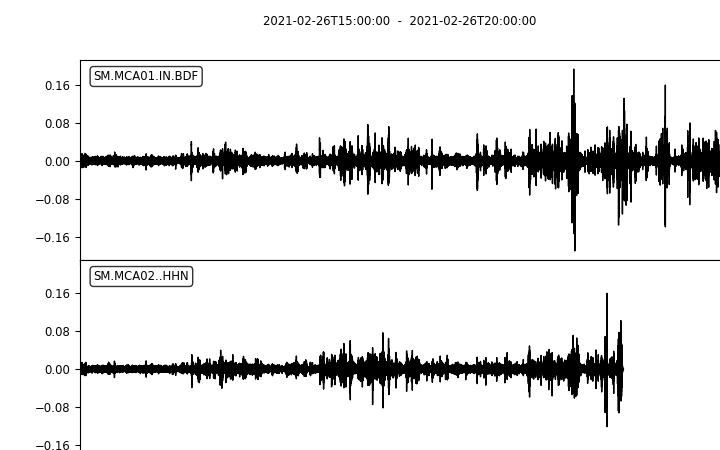

<IPython.core.display.Javascript object>


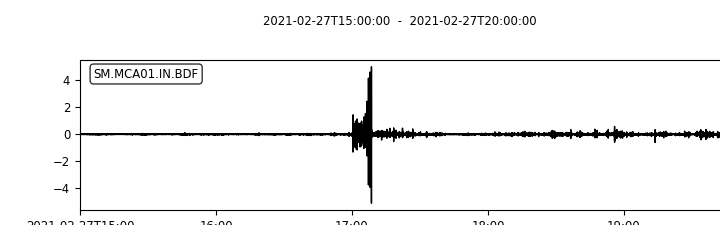

<IPython.core.display.Javascript object>


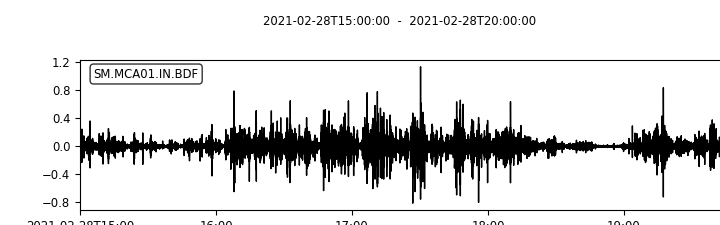

<IPython.core.display.Javascript object>


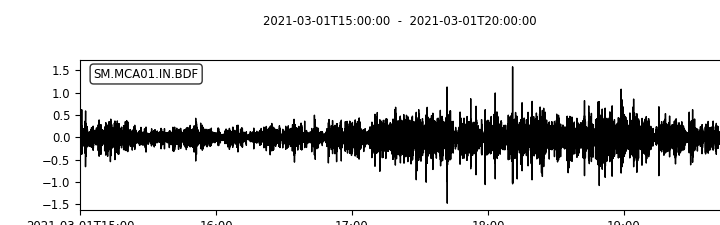

<IPython.core.display.Javascript object>


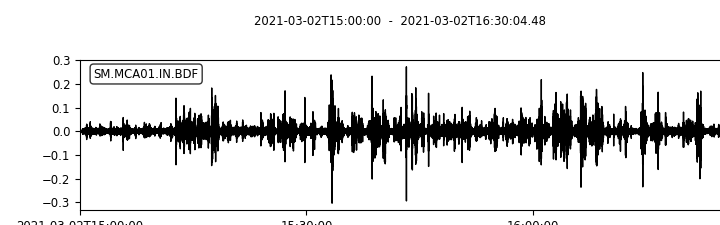

In [2]:
%matplotlib notebook
julian_days = np.arange(11,62,1) # this was to run through everything and check for detections
for day in julian_days:
    # Trim stream - detonations occur mid-day
    if day <= 31: # January
        startTime = UTCDateTime('2021-01-'+str(day)+'T15:00:00')
        endTime = UTCDateTime('2021-01-'+str(day)+'T20:00:00')
    elif (day > 31) and (day <= 59): # February
        day_tmp = day - 31
        startTime = UTCDateTime('2021-02-'+str(day_tmp)+'T15:00:00')
        endTime = UTCDateTime('2021-02-'+str(day_tmp)+'T20:00:00')
    elif day > 59: # March 
        day_tmp = day - 59
        startTime = UTCDateTime('2021-03-'+str(day_tmp)+'T15:00:00')
        endTime = UTCDateTime('2021-03-'+str(day_tmp)+'T20:00:00')
    #-----------------------------------------------------------------------------------------------------------------------#
    # Download data and remove instrument response
    st = mcaap.read_data(day=day, data_dir=[MCA_dir+'MCA01/BDF*/', MCA_dir+'MCA02/HH*/'], loc_dir=MCA_dir+'MCA_BDF_Locations.txt', MCA=True)
    #-----------------------------------------------------------------------------------------------------------------------#
    # Filter trimmed stream to help determine start time
    st.trim(startTime, endTime)
    st_filt = st.copy()
    st_filt.taper(type='cosine', max_percentage=0.05, max_length=60)
    try:
        st_filt.filter('bandpass', freqmin=1, freqmax=10)
    except:
        st_filt = st_filt.split()
        st_filt.filter('bandpass', freqmin=1, freqmax=10)
        st_filt.merge()
    #-----------------------------------------------------------------------------------------------------------------------#
    # Plot filtered stream and save
    st_filt.plot(handle=True, method='full', type='normal', equal_scale=True);

Dates were determined after analyzing array streams and corroborating with GT logs. There was one day with anomalously low SNR which was omitted. Evident wind gusts during days where no detections were observed but shots were detonated.

In [2]:
date_format = '%Y/%m/%d'
dets_dates = ['2021/01/11','2021/01/12','2021/01/13','2021/01/20','2021/01/23',
              '2021/01/26','2021/01/27','2021/01/28','2021/01/29','2021/02/01',
              '2021/02/02','2021/02/03','2021/02/05','2021/02/23','2021/02/25',
              '2021/02/27']
dets_start = ['17:00:00','17:00:00','17:10:00','17:00:00','17:00:00',
              '18:35:00','19:00:00','17:00:00','17:00:00','17:00:00',
              '17:00:00','17:00:00','17:00:00','17:00:00','17:00:00',
              '17:00:00']
dets_end = ['17:30:00','17:30:00','17:30:00','17:30:00','17:15:00',
            '19:05:00','19:30:00','17:30:00','17:30:00','17:15:00',
            '17:15:00','17:15:00','17:30:00','17:20:00','17:30:00',
            '17:15:00']

---
#### Further trimming streams (keep in mind that writing as mseed does not save location info)

In [3]:
%%time
# Further trimming and saving detections
dets_julian_days = []
for date, start, end in zip(dets_dates, dets_start, dets_end):
    st = Stream()
    # Trim stream - detonations occur mid-day
    startTime = UTCDateTime(date.replace('/','-') + 'T' + start)
    endTime = UTCDateTime(date.replace('/','-') + 'T' + end) 
    day = mcaap.YMD_to_JD(date_format, date)[0]; dets_julian_days.append(day)
    # Save start times
    with open(MCA_dir+'MCA_Detections/Signal_Times_CWT/UTC_Starttimes/'+str(day)+'.txt', 'w') as file:
        file.write(str(startTime))
    #-----------------------------------------------------------------------------------------------------------------------#
    # Download data and remove instrument response
    st = mcaap.read_data(day=day, data_dir=[MCA_dir+'MCA01/BDF*/', MCA_dir+'MCA02/HH*/'], loc_dir=MCA_dir+'MCA_BDF_Locations.txt', MCA=True)
    #-----------------------------------------------------------------------------------------------------------------------#
    # Trim stream and save
    st.trim(startTime, endTime)
    try:
        st.write(MCA_dir+'MCA_Detections/Data/MCA_'+str(day)+'.mseed', format='MSEED')
    except:
        st = st.split().copy()
        st.write(MCA_dir+'MCA_Detections/Data/MCA_'+str(day)+'.mseed', format='MSEED')

CPU times: user 3.06 s, sys: 1.41 s, total: 4.46 s
Wall time: 6.95 s


## Blast Sequence Segmentation
---
#### Extracting times of signal peaks using CWT (find_peaks_cwt) to be used for time window construction

Peaks saved for MCA01 - BDF
Figure saved
Peaks saved for MCA02 - HHZ
Figure saved
Peaks saved for MCA02 - HHE
Figure saved
Peaks saved for MCA02 - HHN
Figure saved
CPU times: user 2min 1s, sys: 3.25 s, total: 2min 5s
Wall time: 2min 2s


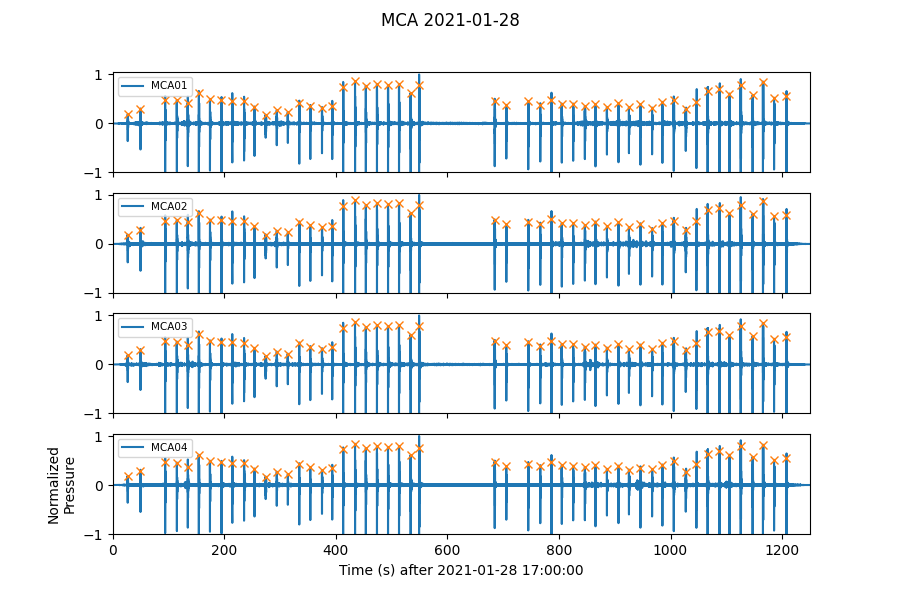

In [4]:
%%time
mcaap.get_signal_times_cwt(day_idx=7, dets_julian_days=dets_julian_days, trim_from_start=None, trim_from_end=550, legend_loc='upper left', legend_size=7.5, MCA=True,
                           scales=[0.1,0.2,0.3,0.4,0.5], min_snr=10, min_distance_secs=15, find_peaks=True, save=True)

Making widths 10x larger resulted in fewer correct peak detections

The cwt works very well for signals with low amplitudes that don't pass the vertical threshold.

---
#### Extracting times using Cardinal

In [5]:
# Constructing frequency bands for Cardinal
f_bands = cardinal.make_custom_fbands(f_min=0.1, f_max=55, win_max=120, type='third_octave')
f_bands['fmax'].values[-1] = np.round(f_bands['fmax'].values[-1],0) - 1 # rounding so f_max becomes Nyquist
f_bands

,band,fmin,fcenter,fmax,win,step
0,1.0,0.100000,0.112996,0.125992,106.518929,10.651893
1,2.0,0.125992,0.142366,0.158740,85.119063,8.511906
2,3.0,0.158740,0.179370,0.200000,68.133978,6.813398
3,4.0,0.200000,0.225992,0.251984,54.652907,5.465291
4,5.0,0.251984,0.284732,0.317480,43.952974,4.395297
5,6.0,0.317480,0.358740,0.400000,35.460432,3.546043
6,7.0,0.400000,0.451984,0.503968,28.719896,2.871990
7,8.0,0.503968,0.569464,0.634960,23.369930,2.336993
8,9.0,0.634960,0.717480,0.800000,19.123658,1.912366
9,10.0,0.800000,0.903968,1.007937,15.753391,1.575339


CPU times: user 9.2 s, sys: 4.95 s, total: 14.1 s
Wall time: 27.9 s


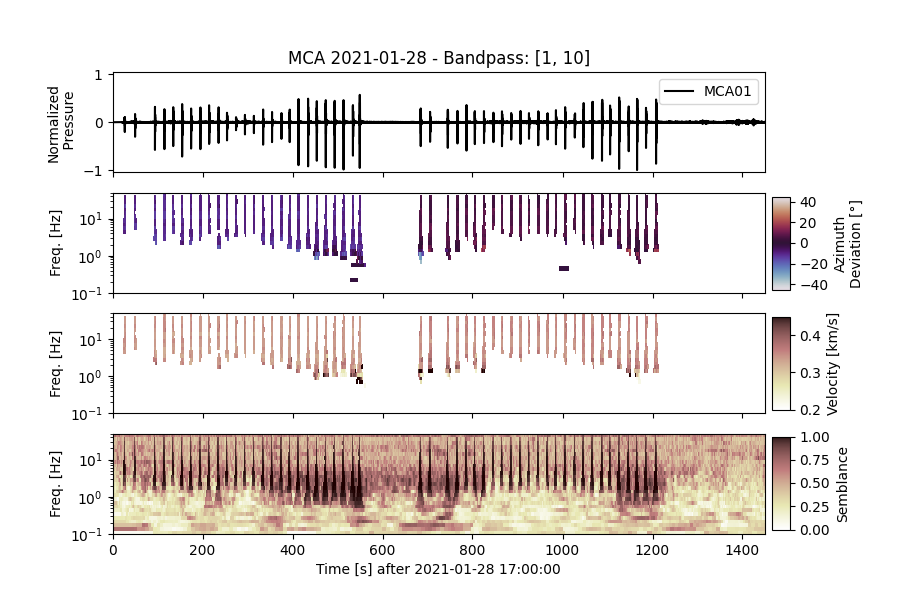

In [10]:
%%time
from dask.distributed import Client
n_workers = 4; client = Client(threads_per_worker=1, n_workers=n_workers, memory_limit='3GB')
# Further trimming and processing detections
for date, start, end in zip(dets_dates, dets_start, dets_end):
    if date == '2021/01/28':
        pass
    else:
        continue
    st = Stream()
    # Trim stream - detonations occur mid-day
    startTime = UTCDateTime(date.replace('/','-') + 'T' + start)
    endTime = UTCDateTime(date.replace('/','-') + 'T' + end) - 30 # fixes endtime problem
    day = mcaap.YMD_to_JD(date_format, date)[0]
    # Save start times
    with open(MCA_dir+'MCA_Detections/Signal_Times_Cardinal/UTC_Starttimes/'+str(day)+'.txt', 'w') as file:
        file.write(str(startTime))
    #-----------------------------------------------------------------------------------------------------------------------#
    # Download data and remove instrument response
    st = mcaap.read_data(day=day, data_dir=[MCA_dir+'MCA01/BDF*/', MCA_dir+'MCA02/HH*/'], loc_dir=MCA_dir+'MCA_BDF_Locations.txt', MCA=True)
    #-----------------------------------------------------------------------------------------------------------------------#
    # Trim stream and save
    st.trim(startTime, endTime)
    try:
        st.write(MCA_dir+'MCA_Detections/Data/MCA_'+str(day)+'.mseed', format='MSEED')
    except:
        st = st.split().copy()
        st.write(MCA_dir+'MCA_Detections/Data/MCA_'+str(day)+'.mseed', format='MSEED')
    #-----------------------------------------------------------------------------------------------------------------------#
    # Run Cardinal
    try:
        T, B, V, S = cardinal.sliding_time_array_fk_multifreq(st, f_bands, client, signal_type="infrasound", adaptive_array=False)
    except:
        st = st.merge() # fixes starttime issue
        T, B, V, S = cardinal.sliding_time_array_fk_multifreq(st, f_bands, client, signal_type="infrasound", adaptive_array=False)
    #-----------------------------------------------------------------------------------------------------------------#
    # Creating families
    ref_time = st[0].stats.starttime.matplotlib_date
    ix, pixels_in_families, families = cardinal.make_families(T, B, V, S, f_bands, ref_time,
                                                          dist_threshold=1, min_pixels=50, sigma_t=2, sigma_f=2, sigma_b=10, p_threshold=0.1, 
                                                          family_grouping='kdtree')
    df = cardinal.df_families(ref_time, families)
    df.to_csv(MCA_dir+'MCA_Detections/Signal_Times_Cardinal/Families/'+str(day)+'.csv', index=False)
    #-----------------------------------------------------------------------------------------------------------------#
    # Plot results
    GT_baz = 226.5 # from Google Earth (back azimuth to Area 1)
    cardinal.plot_sliding_window_multifreq(st, f_bands, T, B, V, S, clim_vtr=[0.2,0.45], clim_baz=[-45,45], normalize=True, amp_units='Pressure [Pa]',
                                           bandpass=[1,10], GT_baz=GT_baz, figsize=(9,6),
                                           ix=ix, pixels_in_families=pixels_in_families,
                                           title='MCA ' + str(st[0].stats.starttime).split('T')[0], fname_plot=MCA_dir+'MCA_Detections/Signal_Times_Cardinal/Plots/'+str(day)+'.png')